In [1]:
# LVDT_simulation/tests/demo.ipynb
import sys
sys.path.append('../../')
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from core import data_handler
from utils.vc_analyser import VC_Calculator

# plt.rcParams['xtick.direction'] = 'in'
# plt.rcParams['ytick.direction'] = 'in'

#### LVDT 

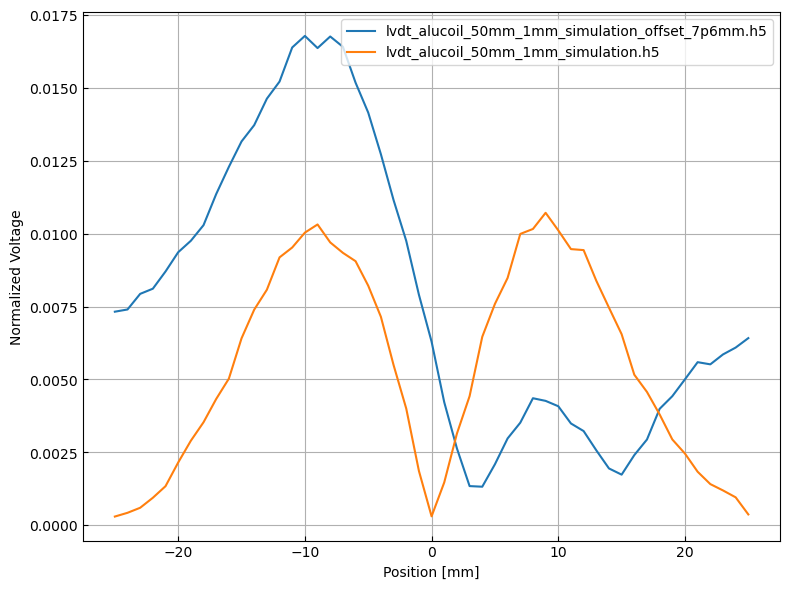

In [4]:
sim_files = ["../data/prototype_validation/lvdt_alucoil_50mm_1mm_simulation_offset_7p6mm.h5",
            "../data/prototype_validation/lvdt_alucoil_50mm_1mm_simulation.h5"]
plt.figure(figsize=(8,6))
for sim_file in sim_files:
    data_dict = data_handler.load_data(sim_file)
    lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)
    sim_pos = lvdt_data['position']
    sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
    sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
    sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 

    plt.plot(sim_pos, sim_pickup_volt_norm, label=sim_file.split('/')[-1])
    plt.xlabel('Position [mm]')
    plt.ylabel('Normalized Voltage')
    plt.tick_params(direction='in')
plt.grid(True)
plt.legend()
plt.tight_layout()

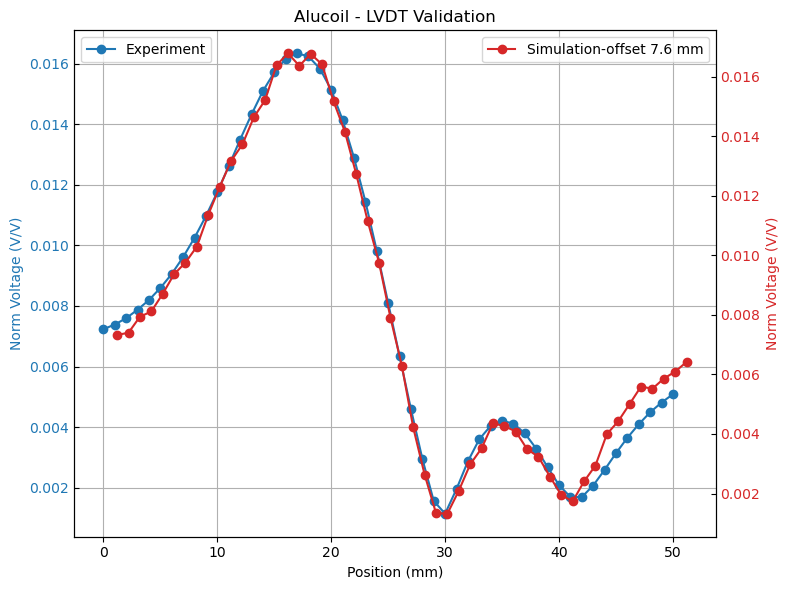

In [5]:
# measurement datas
exp_file = '../data/prototype_validation/lvdt_alucoil_50mm_1mm_measurement_offset.h5'
f = h5py.File(exp_file, 'r')
exp_pos = np.array(f['PI'][:])
exp_pickup_amp = np.array(f['Fit_Amp'][:])
exp_input_waveform = np.array(f['excitation'][:])
exp_pickup_waveform = np.array(f['pick-up'][:])

exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt)

# simulation data
sim_file = "../data/prototype_validation/lvdt_alucoil_50mm_1mm_simulation_offset_7p6mm.h5"
data_dict = data_handler.load_data(sim_file)
lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=False)
sim_pos = lvdt_data['position']+26.2
sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])
sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 

# plot
figure, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(exp_pos, exp_pickup_volt_norm, marker = 'o', label='Experiment', color='tab:blue')
ax1.set_xlabel('Position (mm)')
ax1.set_ylabel('Norm Voltage (V/V)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue', direction='in')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(sim_pos, sim_pickup_volt_norm, marker = 'o', label='Simulation-offset 7.6 mm', color='tab:red')
ax2.set_ylabel('Norm Voltage (V/V)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red', direction='in')
ax2.legend(loc='upper right')
ax1.grid()
plt.title('Alucoil - LVDT Validation')
plt.tight_layout()
plt.savefig('../results/alucoil_lvdt_comp.pdf', dpi=300, bbox_inches='tight')

#### VC

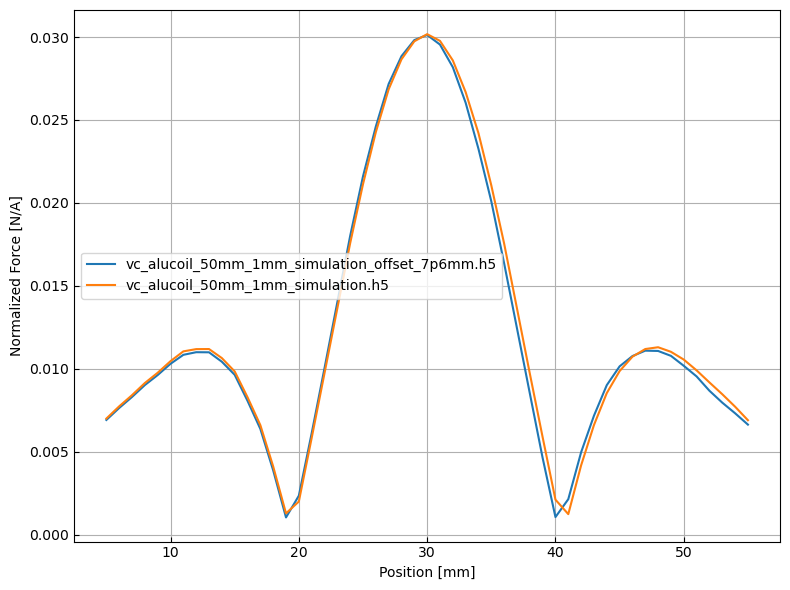

In [6]:
# simulation data
sim_filenames = ["../data/prototype_validation/vc_alucoil_50mm_1mm_simulation_offset_7p6mm.h5",
                "../data/prototype_validation/vc_alucoil_50mm_1mm_simulation.h5"]

plt.figure(figsize=(8,6))
for sim_filename in sim_filenames:
    sim_data_dict = data_handler.load_data(sim_filename)
    sim_config_data = data_handler.get_config_data(sim_data_dict)
    sim_vc_data = data_handler.get_vc_data(sim_data_dict)

    sim_position = sim_vc_data['position']+30
    sim_tot_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
    sim_norm_force = np.array(sim_tot_force)/0.06
    sim_max_norm_force = max(sim_norm_force)
    sim_fvi = ((1 - sim_norm_force )/ sim_max_norm_force) * 100

    plt.plot(sim_position, sim_norm_force, label=sim_filename.split('/')[-1])
    plt.xlabel('Position [mm]')
    plt.ylabel('Normalized Force [N/A]')
    plt.tick_params(direction='in')

plt.grid(True)
plt.legend()
plt.tight_layout()


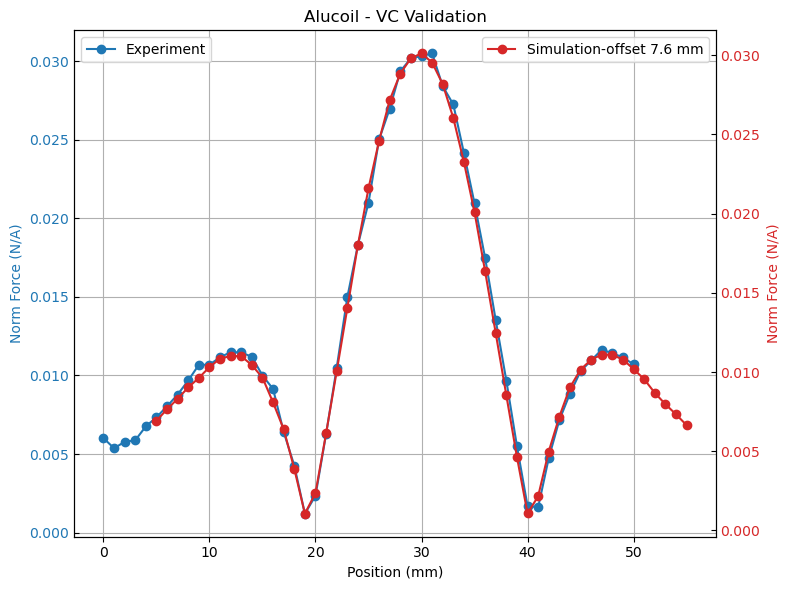

In [9]:
# measurement data
exp_filename = "../data/prototype_validation/vc_alucoil_50mm_1mm_measurement_offset.h5"
vc_calculator = VC_Calculator()
exp_data_dict, curr = vc_calculator.force_calculation(exp_filename, norm=True)
exp_data_sorted = sorted(exp_data_dict.items(), key = lambda item: float(item[0]))

exp_position = []
exp_norm_force = []
for item in exp_data_sorted:
    exp_position.append(float(item[0]))
    exp_norm_force.append(item[1])

# simulation data
sim_filename = "../data/prototype_validation/vc_alucoil_50mm_1mm_simulation_offset_7p6mm.h5"

sim_data_dict = data_handler.load_data(sim_filename)
sim_config_data = data_handler.get_config_data(sim_data_dict)
sim_vc_data = data_handler.get_vc_data(sim_data_dict)

sim_position = sim_vc_data['position']+30
sim_tot_force = abs((sim_vc_data['Lower_Coil']['force'])+(sim_vc_data['Upper_Coil']['force']))
sim_norm_force = np.array(sim_tot_force)/0.06
sim_max_norm_force = max(sim_norm_force)
sim_fvi = ((1 - sim_norm_force )/ sim_max_norm_force) * 100

# plot
figure, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(exp_position, exp_norm_force, marker = 'o', label='Experiment', color='tab:blue')
ax1.set_xlabel('Position (mm)')
ax1.set_ylabel('Norm Force (N/A)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue', direction='in')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(sim_position, sim_norm_force, marker = 'o', label='Simulation-offset 7.6 mm', color='tab:red')
ax2.set_ylabel('Norm Force (N/A)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red', direction='in')
ax2.legend(loc='upper right')
ax1.grid()
plt.title('Alucoil - VC Validation')
plt.tight_layout()
plt.savefig('../results/alucoil_vc_comp.pdf', dpi=300, bbox_inches='tight')